In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [02:15<00:00, 21.3MB/s]



In [3]:
import os

print(os.listdir("/content"))

['.config', 'new-plant-diseases-dataset.zip', 'sample_data']


In [4]:
!unzip -q "/content/new-plant-diseases-dataset.zip" -d "/content/plant_disease"

In [5]:
print(os.listdir("/content/plant_disease/New Plant Diseases Dataset(Augmented)"))

['New Plant Diseases Dataset(Augmented)']


In [6]:
print(os.listdir("/content/plant_disease/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"))

['valid', 'train']


In [7]:
train_dir = "/content/plant_disease/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
test_dir = "/content/plant_disease/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"


In [8]:
print(os.listdir(train_dir))

['Tomato___Septoria_leaf_spot', 'Peach___healthy', 'Cherry_(including_sour)___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Strawberry___healthy', 'Potato___Early_blight', 'Grape___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Bacterial_spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Apple___Apple_scab', 'Raspberry___healthy', 'Grape___Esca_(Black_Measles)', 'Apple___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Tomato___Early_blight', 'Corn_(maize)___healthy', 'Potato___Late_blight', 'Peach___Bacterial_spot', 'Grape___Black_rot', 'Apple___Black_rot', 'Pepper,_bell___healthy', 'Tomato___healthy', 'Soybean___healthy', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Cherry_(including_sour)___Powdery_mildew', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_mosaic_virus', 'Potato___healthy', 'Tomato___Late_blight', 'Apple___Cedar_apple_rust', 'Corn_(maize)___Common_rust_', 'Grape___Leaf_blight_(Isa

In [9]:
data_dir="/content/plant_disease/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"

In [10]:
img_height=128
img_width=128
batch_size=16

In [11]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(img_height,img_width),
    batch_size=batch_size
)

Found 70295 files belonging to 38 classes.


In [12]:
val_ds=tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(img_height,img_width),
    batch_size=batch_size
)

Found 17572 files belonging to 38 classes.


In [13]:
class_names = train_ds.class_names
print(len(class_names))

38


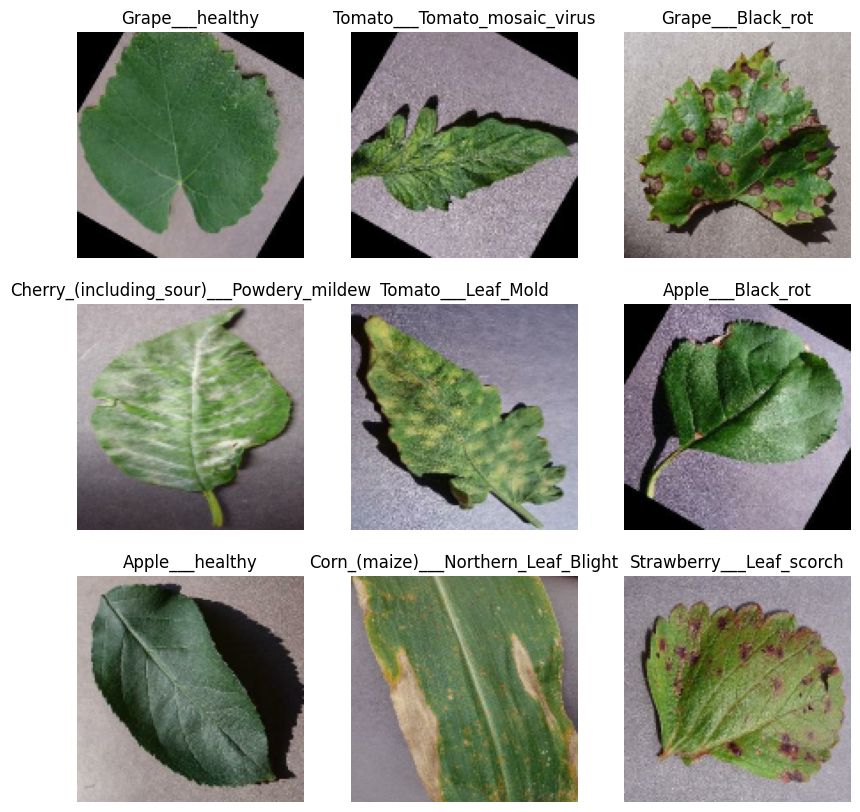

In [14]:
plt.figure(figsize=(10,10))
for images,labels in train_ds.take(1):
  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
  plt.show()

In [15]:
auto=tf.data.AUTOTUNE
train_ds_nm=train_ds.shuffle(1000).prefetch(buffer_size=auto)
val_ds_nm=val_ds.prefetch(buffer_size=auto)

In [16]:
norm_layer=layers.Rescaling(1./255)
norm_train_ds_nm=train_ds_nm.map(lambda x,y:(norm_layer(x),y))
norm_val_ds_nm=val_ds_nm.map(lambda x,y:(norm_layer(x),y))

In [17]:
def create_model():
  model=keras.Sequential([
      layers.InputLayer((img_height,img_width,3)),
      layers.Conv2D(16,3,padding="same",activation="relu"),
      layers.MaxPooling2D(),
      layers.Conv2D(32,3,padding="same",activation="relu"),
      layers.MaxPooling2D(),
      layers.Conv2D(64,3,padding="same",activation="relu"),
      layers.MaxPooling2D(),
      layers.Flatten(),
      layers.Dropout(0.2),
      layers.Dense(128, activation="relu"),
      layers.Dense(len(class_names))
  ])
  model.compile(optimizer="adam",loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=["accuracy"])
  return model

In [18]:
class printdot(keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs):
    if epoch%100==0: print(" ")
    print(".", end=" ")

In [19]:
model=create_model()

In [20]:
early_stop=keras.callbacks.EarlyStopping(monitor="val_loss",patience=10)

In [21]:
history=model.fit(norm_train_ds_nm,validation_data=norm_val_ds_nm,epochs=10,callbacks=[early_stop,printdot()])

Epoch 1/10
4390/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5436 - loss: 1.5968 
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 102s 18ms/step - accuracy: 0.7145 - loss: 0.9476 - val_accuracy: 0.7774 - val_loss: 0.6969
Epoch 2/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 66s 13ms/step - accuracy: 0.8969 - loss: 0.3189 - val_accuracy: 0.9068 - val_loss: 0.2891
Epoch 3/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 81s 13ms/step - accuracy: 0.9326 - loss: 0.2043 - val_accuracy: 0.9154 - val_loss: 0.2683
Epoch 4/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 82s 13ms/step - accuracy: 0.9480 - loss: 0.1556 - val_accuracy: 0.9169 - val_loss: 0.2860
Epoch 5/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 81s 13ms/step - accuracy: 0.9586 - loss: 0.1243 - val_accuracy: 0.9229 - val_loss: 0.2612
Epoch 6/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 75s 15ms/step - accuracy: 0.9650 - loss: 0.1054 - val_accuracy: 0.9117 - val_loss: 0.3210
Epoch 7/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 65s 13ms/step - accuracy: 0.9677 - loss: 0.0982 - val_accuracy: 0.9395 - val_loss: 0.2

In [22]:
hist=pd.DataFrame(history.history)
hist["epoch"]=history.epoch
hist

,accuracy,loss,val_accuracy,val_loss,epoch
0,0.714489,0.947641,0.777430,0.696909,0
1,0.896934,0.318942,0.906840,0.289097,1
2,0.932627,0.204267,0.915434,0.268287,2
3,0.948019,0.155578,0.916913,0.286048,3
4,0.958646,0.124340,0.922889,0.261156,4
5,0.965019,0.105449,0.911678,0.320969,5
6,0.967679,0.098163,0.939506,0.251205,6
7,0.971989,0.084494,0.931425,0.272970,7
8,0.974180,0.083327,0.938482,0.254655,8
9,0.974977,0.080742,0.946392,0.224537,9


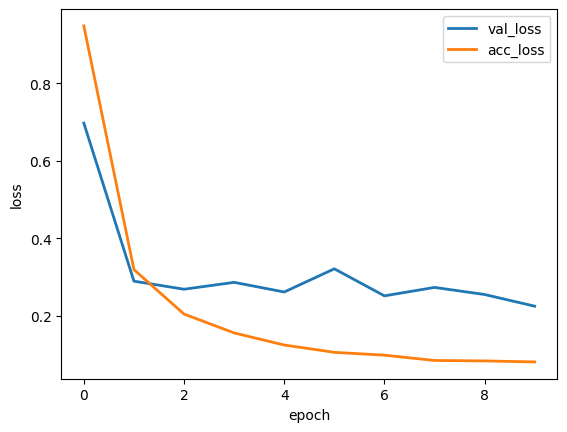

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.plot("val_loss",data=hist,linewidth=2,label="val_loss")
plt.plot("loss",data=hist,linewidth=2,label="acc_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

In [27]:
from PIL import Image
leaf=Image.open("plant_disease.png")

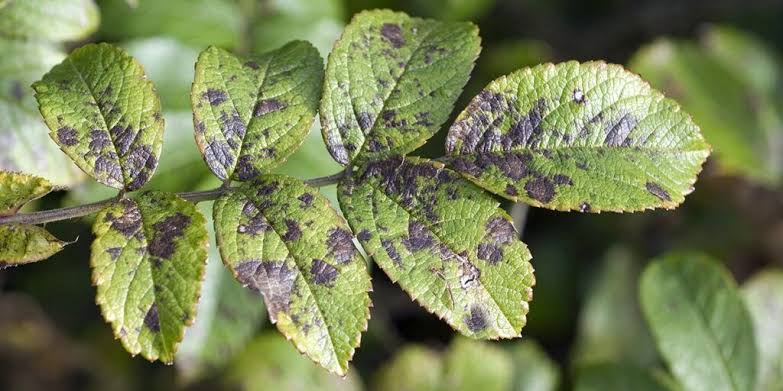

In [28]:
leaf

In [30]:
import numpy as np
import tensorflow as tf

leaf_resized = leaf.resize((img_width, img_height))

leaf_array = np.array(leaf_resized)

leaf_normalized = leaf_array / 255.0

leaf_input = np.expand_dims(leaf_normalized, axis=0)

predictions = model.predict(leaf_input)

predicted_class_index = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_class_index]

print(f"Predicted class: {predicted_class_name}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 595ms/step
Predicted class: Squash___Powdery_mildew
